# belief eye neural analysis


## imports

In [53]:
%reload_ext autoreload
%autoreload 2

In [54]:

import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA
# misc
import pickle
from collections import defaultdict
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

In [55]:
# run this once per notebook session  —  ideally in the first cell
from IPython import get_ipython

def notify_exc(shell, etype, evalue, tb, tb_offset=None):
    # 1. push notification
    summary = f"{etype.__name__}: {evalue}"
    notify(msg=summary, title="Python Error")

    # 2. let IPython show its normal traceback
    shell.showtraceback((etype, evalue, tb), tb_offset=tb_offset)
    return None            # ← must be None or a list of strings

get_ipython().set_custom_exc((Exception,), notify_exc)


## load data

## load standard data


In [56]:
df = pd.read_pickle(resdir/'0506_m51df.pkl')
len(df)
df=df[df.session==41]

In [57]:
def process_one(y):
    related_taskvar=np.array(normalize_z(y))
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    related_taskvar[~mask]=0
    return related_taskvar, mask

def process(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    related_taskvar=np.vstack(rawtaskvar).T
    # related_taskvar=np.clip(related_taskvar,-4,4)
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    mask=np.all(mask, axis=1)
    related_taskvar=related_taskvar[mask]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar
def process_list(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    mask=[(a > -4) & (a < 4) for a in rawtaskvar]
    mask=np.all(mask)
    related_taskvar=[a[mask] for a in rawtaskvar]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar

In [58]:
# error distribution
def get_stop_error(row):
    return ((row.fx[-1]-row.mx[-1])**2+(row.fy[-1]-row.my[-1])**2)**0.5
df['state_error']=df.apply(get_stop_error, axis=1)
def get_stop_error(row):
    return ((row.fx[-1]-row.bmx[-1])**2+(row.fy[-1]-row.bmy[-1])**2)**0.5
df['belief_error']=df.apply(get_stop_error, axis=1)

# time ratio
df['time_ratio']=df.apply(lambda x: x.timer/x.timer[-1], axis=1)


In [59]:
for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessdf.ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timeratio=np.concatenate(sessdf.time_ratio.to_numpy())
timer=np.concatenate(sessdf.timer.to_numpy())
countdown=np.concatenate(sessdf.countdown.to_numpy())


In [60]:
# make a df by time (each row is a time, instead of a trial)
sessdf['density_t']=sessdf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessdf['fullon_t']=sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessdf['error_t']=sessdf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)



timedf=pd.DataFrame({'timer':timer})
timedf['rawcov']=list(np.vstack(sessdf['rawcov'].to_numpy()))
timedf['belief']=np.concatenate(sessdf.belief_ff_hori.to_numpy())
timedf['state']=np.concatenate(sessdf.ff_hori.to_numpy())
timedf['eye']=np.concatenate(sessdf.eye_hori.to_numpy())
timedf['timeratio']=np.concatenate(sessdf.time_ratio.to_numpy())
timedf['mv']=np.concatenate(sessdf.mv.to_numpy())
timedf['mw']=np.concatenate(sessdf.mw.to_numpy())
timedf['belief_heading']=np.concatenate(sessdf.belief_heading.to_numpy())
timedf['timer']=np.concatenate(sessdf.timer.to_numpy())
timedf['countdown']=np.concatenate(sessdf.countdown.to_numpy())
timedf['belief_angle_from_start']=np.concatenate(sessdf.belief_angle_from_start.to_numpy())
timedf['PPC']=list(np.vstack(sessdf.PPC.to_numpy()))

timedf['uncertainty']=list(np.concatenate(sessdf.relcov.to_numpy()))
timedf['density']=np.concatenate(sessdf.density_t.to_numpy())
timedf['fullon']=np.concatenate(sessdf.fullon_t.to_numpy())
timedf['error']=np.concatenate(sessdf.error_t.to_numpy())
timedf['trial'] = np.concatenate(sessdf.apply(lambda x: np.full(len(x.mx), x.trial), axis=1).to_numpy())

timedf['dbelief']=np.concatenate(sessdf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timedf['deye']=np.concatenate(sessdf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timedf['dneural']=list(np.vstack(sessdf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timedf.head()
timedf = timedf.dropna(subset=['eye', 'state', 'belief'])

## load iti data

In [61]:
itidf = pd.read_pickle(resdir/'0421iti_m51df.pkl')
len(itidf)
itidf=itidf[itidf.session==41]
itidf['time_ratio']=itidf.apply(lambda x: x.timer/x.timer[-1], axis=1)

In [62]:
for session in sorted(itidf.session.unique())[:1]:
    sessitidf=itidf[(itidf.session==session)]

# state=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessitidf.ff_hori.to_numpy())
eye=np.concatenate(sessitidf.eye_hori.to_numpy())
timeratio=np.concatenate(sessitidf.time_ratio.to_numpy())
timer=np.concatenate(sessitidf.timer.to_numpy())
countdown=np.concatenate(sessitidf.countdown.to_numpy())

# make a itidf by time (each row is a time, instead of a trial)
sessitidf['density_t']=sessitidf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['fullon_t']=sessitidf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['error_t']=sessitidf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timeitidf=pd.DataFrame({'timer':timer})
# timeitidf['rawcov']=list(np.vstack(sessitidf['rawcov'].to_numpy()))
# timeitidf['belief']=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
timeitidf['state']=np.concatenate(sessitidf.ff_hori.to_numpy())
timeitidf['eye']=np.concatenate(sessitidf.eye_hori.to_numpy())
timeitidf['timeratio']=np.concatenate(sessitidf.time_ratio.to_numpy())
timeitidf['mv']=np.concatenate(sessitidf.mv.to_numpy())
timeitidf['mw']=np.concatenate(sessitidf.mw.to_numpy())
# timeitidf['belief_heading']=np.concatenate(sessitidf.belief_heading.to_numpy())
timeitidf['timer']=np.concatenate(sessitidf.timer.to_numpy())
timeitidf['countdown']=np.concatenate(sessitidf.countdown.to_numpy())
# timeitidf['belief_angle_from_start']=np.concatenate(sessitidf.belief_angle_from_start.to_numpy())
timeitidf['PPC']=list(np.vstack(sessitidf.PPC.to_numpy()))

# timeitidf['uncertainty']=list(np.concatenate(sessitidf.relcov.to_numpy()))

timeitidf['density']=np.concatenate(sessitidf.density_t.to_numpy())
timeitidf['fullon']=np.concatenate(sessitidf.fullon_t.to_numpy())
timeitidf['error']=np.concatenate(sessitidf.error_t.to_numpy())


# timeitidf['dbelief']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['deye']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['dneural']=list(np.vstack(sessitidf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timeitidf.head()
# timeitidf = timeitidf.dropna(subset=['eye', 'state'])

,timer,state,eye,timeratio,mv,mw,countdown,PPC,density,fullon,error,deye,dneural
0,0,-0.411339,28.940651,0.000000,-0.003190,-0.001378,-37,"[0.106192164, 0.19640955, 0.0, 0.0, 0.05650172...",0.005,0,174.501175,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,1,-0.470667,28.920336,0.027027,0.023303,0.007235,-36,"[0.10775572, 0.1846899, 0.0, 3.3458742e-05, 0....",0.005,0,174.501175,-0.020315,"[0.0015635565, -0.011719659, 0.0, 3.3458742e-0..."
2,2,-0.533338,28.902283,0.054054,-0.004524,-0.002155,-35,"[0.109807715, 0.16330647, 0.0, 8.815204e-05, 0...",0.005,0,174.501175,-0.018053,"[0.0020519942, -0.02138342, 0.0, 5.4693297e-05..."
3,3,-0.500699,28.880598,0.081081,-0.015537,-0.000820,-34,"[0.110675946, 0.13578184, 0.0, 0.0002181784, 0...",0.005,0,174.501175,-0.021685,"[0.00086823106, -0.027524635, 0.0, 0.000130026..."
4,4,-0.481149,28.881540,0.108108,0.015418,0.008251,-33,"[0.10878229, 0.10615871, 0.0, 0.00050727994, 0...",0.005,0,174.501175,0.000942,"[-0.0018936545, -0.029623128, 0.0, 0.000289101..."


# done

In [13]:
neural_data = np.vstack(timedf['PPC'].to_numpy())
belief_data = timedf['belief'].to_numpy()
eye_data = timedf['eye'].to_numpy()


import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# Ensure all inputs are numpy arrays
X = neural_data  # [T, N]
y_belief = np.vstack(belief_data)  # [T, D1]
y_eye = np.vstack(eye_data)        # [T, D2]

# Optional: z-score inputs (standardizing helps Lasso)
X = (X - X.mean(0)) / X.std(0)

def crossval_lasso(X, Y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    y_true_all, y_pred_all = [], []

    for train_idx, test_idx in kf.split(X):
        model = LassoCV(cv=5, max_iter=10000)
        model.fit(X[train_idx], Y[train_idx])
        y_pred = model.predict(X[test_idx])
        y_true_all.append(Y[test_idx])
        y_pred_all.append(y_pred)

    y_true_all = np.concatenate(y_true_all, axis=0)
    y_pred_all = np.concatenate(y_pred_all, axis=0)
    r2 = r2_score(y_true_all, y_pred_all)
    return r2

# Run for each prediction target
r2_belief = crossval_lasso(X, y_belief)
r2_eye = crossval_lasso(X, y_eye)

print(f'Cross-validated R² (neural → belief): {r2_belief:.3f}')
print(f'Cross-validated R² (neural → eye): {r2_eye:.3f}')


Cross-validated R² (neural → belief): 0.252
Cross-validated R² (neural → eye): 0.410


In [ ]:
# import numpy as np
# from sklearn.linear_model import RidgeCV
# from sklearn.model_selection import KFold
# from sklearn.metrics import r2_score
# from sklearn.preprocessing import StandardScaler

# # Inputs: 
# # neural_data: [T, N] - neural features (e.g., spike rates)
# # belief_data: [T, D1] - belief variables (can be 1D or 2D)
# # eye_data: [T, D2] - eye variables

# def standardize(X):
#     return (X - X.mean(0)) / X.std(0)

# def crossval_ridge(X, Y, n_splits=5, alphas=np.logspace(-3, 3, 10)):
#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
#     y_true_all, y_pred_all = [], []

#     for train_idx, test_idx in kf.split(X):
#         X_train, X_test = X[train_idx], X[test_idx]
#         Y_train, Y_test = Y[train_idx], Y[test_idx]

#         model = RidgeCV(alphas=alphas, store_cv_values=False)
#         model.fit(X_train, Y_train)

#         Y_pred = model.predict(X_test)
#         y_true_all.append(Y_test)
#         y_pred_all.append(Y_pred)

#     y_true_all = np.vstack(y_true_all)
#     y_pred_all = np.vstack(y_pred_all)

#     r2 = r2_score(y_true_all, y_pred_all, multioutput='uniform_average')
#     return r2

# # Example usage
# X = standardize(neural_data)               # [T, N]
# Y_belief = standardize(np.array(belief_data))  # [T, D1]
# Y_eye = standardize(np.array(eye_data))        # [T, D2]

# r2_belief = crossval_ridge(X, Y_belief)
# r2_eye = crossval_ridge(X, Y_eye)

# print(f'Cross-validated R² (neural → belief): {r2_belief:.3f}')
# print(f'Cross-validated R² (neural → eye): {r2_eye:.3f}')


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 80024 and the array at index 2 has size 80023

In [22]:
import numpy as np
import statsmodels.api as sm

# Inputs: [T, N] and [T, D]
neural_data = np.vstack(timedf['PPC'].to_numpy())        # [T, N]
eye_data = np.vstack(timedf['eye'].to_numpy())           # [T, 2]
belief_data = np.vstack(timedf['belief'].to_numpy())     # [T, D]

# Remove NaNs
X_eye = eye_data
X_belief = belief_data
X_all = np.hstack([X_eye, X_belief])
valid = np.isfinite(X_all).all(1) & np.isfinite(neural_data).all(1)

X_eye = X_eye[valid]
X_belief = X_belief[valid]
y_all = neural_data[valid]
X_all = np.hstack([X_eye, X_belief])
X_design_full = sm.add_constant(X_all)
X_design_eye = sm.add_constant(X_eye)
X_design_belief = sm.add_constant(X_belief)

# Store results
unique_eye_r2 = []
unique_belief_r2 = []
total_r2 = []

for i in range(y_all.shape[1]):
    y = y_all[:, i]

    # Full model: eye + belief
    model_full = sm.GLM(y, X_design_full, family=sm.families.Gaussian()).fit()
    pred_full = model_full.predict(X_design_full)
    r2_full = 1 - np.sum((y - pred_full)**2) / np.sum((y - np.mean(y))**2)

    # No eye: only belief
    model_belief = sm.GLM(y, X_design_belief, family=sm.families.Gaussian()).fit()
    pred_belief = model_belief.predict(X_design_belief)
    r2_belief = 1 - np.sum((y - pred_belief)**2) / np.sum((y - np.mean(y))**2)

    # No belief: only eye
    model_eye = sm.GLM(y, X_design_eye, family=sm.families.Gaussian()).fit()
    pred_eye = model_eye.predict(X_design_eye)
    r2_eye = 1 - np.sum((y - pred_eye)**2) / np.sum((y - np.mean(y))**2)

    # Partition
    unique_eye_r2.append(r2_full - r2_belief)
    unique_belief_r2.append(r2_full - r2_eye)
    total_r2.append(r2_full)

# Convert to array
unique_eye_r2 = np.array(unique_eye_r2)
unique_belief_r2 = np.array(unique_belief_r2)
total_r2 = np.array(total_r2)

# Print summary
print(f"Mean total R²: {np.mean(total_r2):.4f}")
print(f"Mean unique eye R²: {np.mean(unique_eye_r2):.4f}")
print(f"Mean unique belief R²: {np.mean(unique_belief_r2):.4f}")


Mean total R²: 0.0082
Mean unique eye R²: 0.0040
Mean unique belief R²: 0.0021


In [24]:
timedf.columns

Index(['timer', 'rawcov', 'belief', 'state', 'eye', 'timeratio', 'mv', 'mw',
       'belief_heading', 'countdown', 'belief_angle_from_start', 'PPC',
       'uncertainty', 'density', 'fullon', 'error', 'dbelief', 'deye',
       'dneural'],
      dtype='object')

In [ ]:
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# 1. Load predictors (each is shape [T, 1])
eye = np.vstack(timedf['eye'].to_numpy())          # [T, 1]
state = np.vstack(timedf['state'].to_numpy())      # [T, 1]
timer = timedf['timer'].to_numpy().reshape(-1, 1)  # [T, 1]
mw = timedf['mw'].to_numpy().reshape(-1, 1)        # [T, 1]
fr = np.vstack(timedf['PPC'].to_numpy())           # [T, N]

# 2. Add one lag of firing rate as spike history
lag = 1
fr_lagged = np.roll(fr, lag, axis=0)
fr_lagged[:lag, :] = np.nan  # mask first row

# 3. Build base design matrix: [T, 5]
X_base = np.hstack([eye, state, timer, mw, fr_lagged])

# 4. Remove rows with any NaNs
valid = np.isfinite(X_base).all(axis=1) & np.isfinite(fr).all(axis=1)
X_base = X_base[valid]
fr = fr[valid]

# 5. Setup RidgeCV
alphas = np.logspace(-3, 3, 10)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
n_neurons = fr.shape[1]
r2s = []

# 6. Loop over neurons
for i in range(n_neurons):
    print(f"Neuron {i+1}/{n_neurons}...")
    y = fr[:, i]
    y_pred_all, y_true_all = [], []

    for train_idx, test_idx in kf.split(X_base):
        ridge = RidgeCV(alphas=alphas)
        ridge.fit(X_base[train_idx], y[train_idx])
        y_pred = ridge.predict(X_base[test_idx])
        y_pred_all.append(y_pred)
        y_true_all.append(y[test_idx])

    y_pred_all = np.concatenate(y_pred_all)
    y_true_all = np.concatenate(y_true_all)
    r2 = r2_score(y_true_all, y_pred_all)
    r2s.append(r2)

# 7. Report result
print(f"\nModel 1 (Base): Mean cross-validated pseudo-R² across neurons = {np.mean(r2s):.4f}")


Neuron 1/112...
Neuron 2/112...
Neuron 3/112...
Neuron 4/112...


KeyboardInterrupt: 

In [29]:
# fix alpha ridge, faster
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# 1. Load predictors (each is shape [T, 1])
eye = np.vstack(timedf['eye'].to_numpy())          
state = np.vstack(timedf['state'].to_numpy())      
timer = timedf['timer'].to_numpy().reshape(-1, 1)  
mw = timedf['mw'].to_numpy().reshape(-1, 1)        
fr = np.vstack(timedf['PPC'].to_numpy())           

# 2. Spike history (1 lag)
lag = 1
fr_lagged = np.roll(fr, lag, axis=0)
fr_lagged[:lag, :] = np.nan

# 3. Design matrix
X_base = np.hstack([eye, state, timer, mw, fr_lagged])
valid = np.isfinite(X_base).all(axis=1) & np.isfinite(fr).all(axis=1)
X_base = X_base[valid]
fr = fr[valid]

# 4. Fixed-alpha ridge
ridge = Ridge(alpha=10.0)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
r2s = []

# 5. Per-neuron loop
for i in range(fr.shape[1]):
    print(f"Neuron {i+1}/{fr.shape[1]}...")
    y = fr[:, i]
    y_true_all, y_pred_all = [], []

    for train_idx, test_idx in kf.split(X_base):
        ridge.fit(X_base[train_idx], y[train_idx])
        y_pred = ridge.predict(X_base[test_idx])
        y_pred_all.append(y_pred)
        y_true_all.append(y[test_idx])

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    r2 = r2_score(y_true_all, y_pred_all)
    r2s.append(r2)

print(f"\nModel 1 (Base): Mean cross-validated pseudo-R² = {np.mean(r2s):.4f}")


Neuron 1/112...
Neuron 2/112...
Neuron 3/112...
Neuron 4/112...
Neuron 5/112...
Neuron 6/112...
Neuron 7/112...
Neuron 8/112...
Neuron 9/112...
Neuron 10/112...
Neuron 11/112...
Neuron 12/112...
Neuron 13/112...
Neuron 14/112...
Neuron 15/112...
Neuron 16/112...
Neuron 17/112...
Neuron 18/112...
Neuron 19/112...
Neuron 20/112...
Neuron 21/112...
Neuron 22/112...
Neuron 23/112...
Neuron 24/112...
Neuron 25/112...
Neuron 26/112...
Neuron 27/112...
Neuron 28/112...
Neuron 29/112...
Neuron 30/112...
Neuron 31/112...
Neuron 32/112...
Neuron 33/112...
Neuron 34/112...
Neuron 35/112...
Neuron 36/112...
Neuron 37/112...
Neuron 38/112...
Neuron 39/112...
Neuron 40/112...
Neuron 41/112...
Neuron 42/112...
Neuron 43/112...
Neuron 44/112...
Neuron 45/112...
Neuron 46/112...
Neuron 47/112...
Neuron 48/112...
Neuron 49/112...
Neuron 50/112...
Neuron 51/112...
Neuron 52/112...
Neuron 53/112...
Neuron 54/112...
Neuron 55/112...
Neuron 56/112...
Neuron 57/112...
Neuron 58/112...
Neuron 59/112...
Neuron

In [31]:
# dorp 1 analysis
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# 1. Load predictors
eye = np.vstack(timedf['eye'].to_numpy())          # [T, 1]
state = np.vstack(timedf['state'].to_numpy())      # [T, 1]
timer = timedf['timer'].to_numpy().reshape(-1, 1)  # [T, 1]
mw = timedf['mw'].to_numpy().reshape(-1, 1)        # [T, 1]
fr = np.vstack(timedf['PPC'].to_numpy())           # [T, N]

# 2. Spike history
lag = 1
fr_lagged = np.roll(fr, lag, axis=0)
fr_lagged[:lag, :] = np.nan

# 3. Build full design matrix
X_full = np.hstack([eye, state, timer, mw, fr_lagged])
valid = np.isfinite(X_full).all(axis=1) & np.isfinite(fr).all(axis=1)
X_full = X_full[valid]
eye = eye[valid]
state = state[valid]
timer = timer[valid]
mw = mw[valid]
fr_lagged = fr_lagged[valid]
fr = fr[valid]

# 4. Ridge setup
ridge = Ridge(alpha=10.0)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
n_neurons = fr.shape[1]

# 5. Function to compute cross-validated R²
def crossval_r2(X, y):
    y_true_all, y_pred_all = [], []
    for train_idx, test_idx in kf.split(X):
        ridge.fit(X[train_idx], y[train_idx])
        y_pred = ridge.predict(X[test_idx])
        y_true_all.append(y[test_idx])
        y_pred_all.append(y_pred)
    return r2_score(np.concatenate(y_true_all), np.concatenate(y_pred_all))

# 6. Storage
r2_full = []
r2_no_eye = []
r2_no_state = []
r2_no_timer = []
r2_no_mw = []
r2_no_hist = []

# 7. Loop over neurons
for i in range(n_neurons):
    print(f"Neuron {i+1}/{n_neurons}...")
    y = fr[:, i]

    # Full model
    r2_full.append(crossval_r2(X_full, y))

    # Drop one group at a time
    r2_no_eye.append(crossval_r2(np.hstack([state, timer, mw, fr_lagged]), y))
    r2_no_state.append(crossval_r2(np.hstack([eye, timer, mw, fr_lagged]), y))
    r2_no_timer.append(crossval_r2(np.hstack([eye, state, mw, fr_lagged]), y))
    r2_no_mw.append(crossval_r2(np.hstack([eye, state, timer, fr_lagged]), y))
    r2_no_hist.append(crossval_r2(np.hstack([eye, state, timer, mw]), y))

# 8. Convert to arrays
r2_full = np.array(r2_full)
unique_eye = r2_full - np.array(r2_no_eye)
unique_state = r2_full - np.array(r2_no_state)
unique_timer = r2_full - np.array(r2_no_timer)
unique_mw = r2_full - np.array(r2_no_mw)
unique_hist = r2_full - np.array(r2_no_hist)

# 9. Print results
print(f"Mean R² (full model): {np.mean(r2_full):.4f}")
print(f"Unique contribution:")
print(f"  Eye:   {np.mean(unique_eye):.4f}")
print(f"  State: {np.mean(unique_state):.4f}")
print(f"  Timer: {np.mean(unique_timer):.4f}")
print(f"  MW:    {np.mean(unique_mw):.4f}")
print(f"  Hist:  {np.mean(unique_hist):.4f}")



Neuron 1/112...
Neuron 2/112...


KeyboardInterrupt: 

Fitting neuron 1/10...
Fitting neuron 2/10...
Fitting neuron 3/10...
Fitting neuron 4/10...
Fitting neuron 5/10...
Fitting neuron 6/10...
Fitting neuron 7/10...
Fitting neuron 8/10...
Fitting neuron 9/10...
Fitting neuron 10/10...


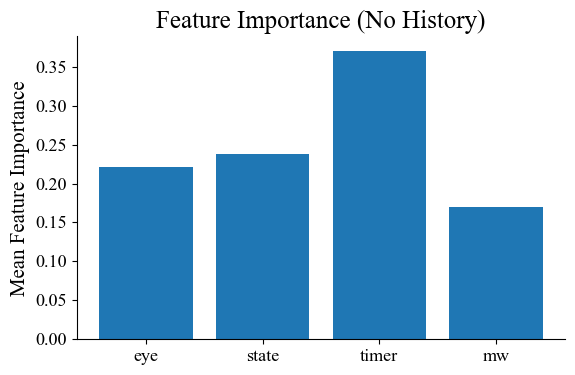


Mean R² without history: 0.2274


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Load inputs
eye = np.vstack(timedf['eye'].to_numpy())          # [T, 1]
state = np.vstack(timedf['state'].to_numpy())      # [T, 1]
timer = timedf['timer'].to_numpy().reshape(-1, 1)  # [T, 1]
mw = timedf['mw'].to_numpy().reshape(-1, 1)        # [T, 1]
fr = np.vstack(timedf['PPC'].to_numpy())[:,:10]           # [T, N]

# 2. Build input matrix without spike history
X = np.hstack([eye, state, timer, mw])
feature_names = ['eye', 'state', 'timer', 'mw']

# 3. Remove invalid rows
valid = np.isfinite(X).all(axis=1) & np.isfinite(fr).all(axis=1)
X = X[valid]
fr = fr[valid]

# 4. Train model and collect feature importances
importances_all = []
r2_all = []

for i in range(fr.shape[1]):
    print(f"Fitting neuron {i+1}/{fr.shape[1]}...")
    y = fr[:, i]

    model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=0, n_jobs=-1)
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    r2_all.append(r2)
    importances_all.append(model.feature_importances_)

importances_all = np.array(importances_all)  # [neurons, features]

# 5. Plot average importance
mean_importance = np.mean(importances_all, axis=0)

plt.figure(figsize=(6, 4))
plt.bar(feature_names, mean_importance)
plt.ylabel("Mean Feature Importance")
plt.title("Feature Importance (No History)")
plt.tight_layout()
plt.show()

# 6. Optional: print R² summary
print(f"\nMean R² without history: {np.mean(r2_all):.4f}")


Fitting neuron 1/10...
Fitting neuron 2/10...
Fitting neuron 3/10...
Fitting neuron 4/10...
Fitting neuron 5/10...
Fitting neuron 6/10...
Fitting neuron 7/10...
Fitting neuron 8/10...
Fitting neuron 9/10...
Fitting neuron 10/10...


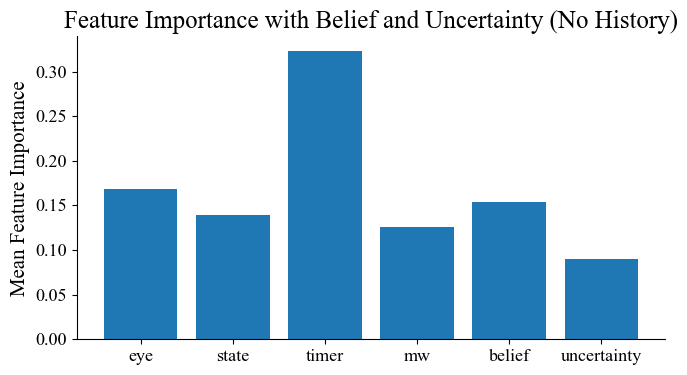


Mean R² without history (with belief + uncertainty): 0.2501


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Load inputs
eye = np.vstack(timedf['eye'].to_numpy())          # [T, 1]
state = np.vstack(timedf['state'].to_numpy())      # [T, 1]
timer = timedf['timer'].to_numpy().reshape(-1, 1)  # [T, 1]
mw = timedf['mw'].to_numpy().reshape(-1, 1)        # [T, 1]
belief = np.vstack(timedf['belief'].to_numpy())    # [T, 1]
uncertainty = np.array([u[0, 0] for u in timedf['uncertainty'].to_numpy()]).reshape(-1, 1)
  # [T, 1]
fr = np.vstack(timedf['PPC'].to_numpy())[:,:10]           # [T, N]

# 2. Combine all predictors (excluding spike history)
X = np.hstack([eye, state, timer, mw, belief, uncertainty])
feature_names = ['eye', 'state', 'timer', 'mw', 'belief', 'uncertainty']

# 3. Remove invalid rows
valid = np.isfinite(X).all(axis=1) & np.isfinite(fr).all(axis=1)
X = X[valid]
fr = fr[valid]

# 4. Train random forest per neuron
importances_all = []
r2_all = []

for i in range(fr.shape[1]):
    print(f"Fitting neuron {i+1}/{fr.shape[1]}...")
    y = fr[:, i]

    model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=0, n_jobs=-1)
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    r2_all.append(r2)
    importances_all.append(model.feature_importances_)

importances_all = np.array(importances_all)  # shape: [neurons, features]

# 5. Plot average importance
mean_importance = np.mean(importances_all, axis=0)

plt.figure(figsize=(7, 4))
plt.bar(feature_names, mean_importance)
plt.ylabel("Mean Feature Importance")
plt.title("Feature Importance with Belief and Uncertainty (No History)")
plt.tight_layout()
plt.show()

# 6. Optional: mean model fit
print(f"\nMean R² without history (with belief + uncertainty): {np.mean(r2_all):.4f}")


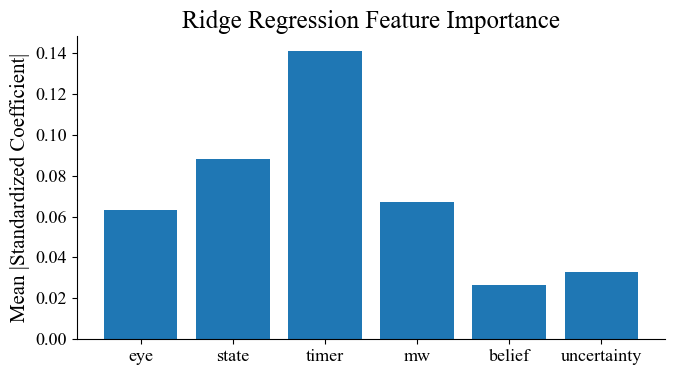

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# 1. Load predictors
eye = np.vstack(timedf['eye'].to_numpy())
state = np.vstack(timedf['state'].to_numpy())
timer = timedf['timer'].to_numpy().reshape(-1, 1)
mw = timedf['mw'].to_numpy().reshape(-1, 1)
belief = np.vstack(timedf['belief'].to_numpy())
uncertainty = np.array([u[0, 0] for u in timedf['uncertainty'].to_numpy()]).reshape(-1, 1)
fr = np.vstack(timedf['PPC'].to_numpy())[:,:10]  # [T, N]

# 2. Combine predictors
X = np.hstack([eye, state, timer, mw, belief, uncertainty])
feature_names = ['eye', 'state', 'timer', 'mw', 'belief', 'uncertainty']

# 3. Remove NaNs
valid = np.isfinite(X).all(axis=1) & np.isfinite(fr).all(axis=1)
X = X[valid]
fr = fr[valid]

# 4. Standardize predictors
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# 5. Collect standardized coefficients across neurons
coefs_all = []

for i in range(fr.shape[1]):
    y = fr[:, i]
    y_scaled = StandardScaler().fit_transform(y.reshape(-1, 1)).flatten()

    model = Ridge(alpha=10.0)
    model.fit(X_scaled, y_scaled)
    coefs_all.append(model.coef_)

coefs_all = np.array(coefs_all)  # [neurons, features]

# 6. Plot mean |coefficient| across neurons
mean_importance = np.mean(np.abs(coefs_all), axis=0)

plt.figure(figsize=(7, 4))
plt.bar(feature_names, mean_importance)
plt.ylabel("Mean |Standardized Coefficient|")
plt.title("Ridge Regression Feature Importance")
plt.tight_layout()
plt.show()


In [9]:
timedf.columns, sessdf.columns

(Index(['timer', 'rawcov', 'belief', 'state', 'eye', 'timeratio', 'mv', 'mw',
        'belief_heading', 'countdown', 'belief_angle_from_start', 'PPC',
        'uncertainty', 'density', 'fullon', 'error', 'trial', 'dbelief', 'deye',
        'dneural'],
       dtype='object'),
 Index(['trial', 'session', 'fullon', 'ptb', 'density', 'heading', 'fx', 'fy',
        'mx', 'my', 'mv', 'mw', 'egofx', 'egofy', 'eye_hori', 'eye_vert',
        'ff_hori', 'ff_vert', 'PPC', 'PPC_var', 'PFC', 'PFC_var', 'MST',
        'MST_var', 'VIP', 'VIP_var', 'error', 'error_sign', 'target_angle',
        'target_distance', 'state', 'action', 'task', 'likelihood', 'belief',
        'rawcov', 'bmx', 'bmy', 'belief_heading', 'timer', 'countdown',
        'belief_ff_hori', 'belief_ff_vert', 'angle_from_start',
        'belief_angle_from_start', 'relcov', 'state_error', 'belief_error',
        'time_ratio', 'density_t', 'fullon_t', 'error_t'],
       dtype='object'))

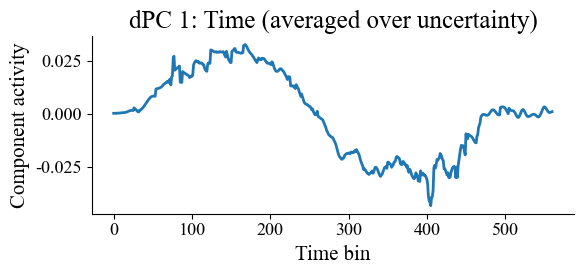

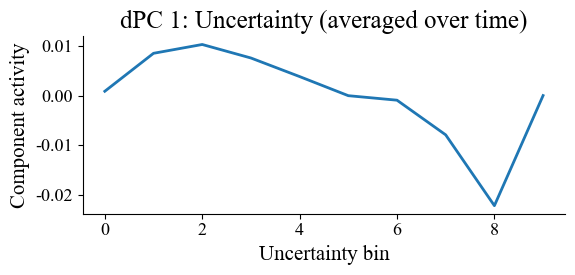

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dPCA.dPCA import dPCA

# === Load data ===
fr = np.vstack(timedf['PPC'].to_numpy())           # [T_total, N_neurons]
uncertainty = np.array([u[0, 0] for u in timedf['uncertainty'].to_numpy()]).reshape(-1, 1)
time_bin = timedf['timer'].to_numpy()              # assumed int bin index

n_neurons = fr.shape[1]
n_time_bins = int(np.max(time_bin)) + 1
n_bins_uncert = 10

# === Bin uncertainty ===
uncert_bin = pd.qcut(uncertainty.flatten(), q=n_bins_uncert, labels=False, duplicates='drop')

# === Create data tensor: [neurons, time, uncertainty_bin] ===
X = np.full((n_neurons, n_time_bins, n_bins_uncert), np.nan)

for u in range(n_bins_uncert):
    idx_u = (uncert_bin == u)
    for t in range(n_time_bins):
        idx = idx_u & (time_bin == t)
        if np.any(idx):
            fr_slice = fr[idx]                              # [samples x neurons]
            X[:, t, u] = np.nanmean(fr_slice, axis=0)

# === Fill missing with neuron-wise global mean ===
X_mean = np.nanmean(X, axis=(1, 2), keepdims=True)
X = np.where(np.isnan(X), X_mean, X)

# === Run dPCA ===
dpca = dPCA(labels='tu', regularizer=1e-5)
Z = dpca.fit_transform(X)

# === Plotting ===

# --- Time component (averaged across uncertainty bins) ---
plt.figure(figsize=(6, 3))
plt.plot(np.mean(Z['t'][0], axis=1))  # [time]
plt.title("dPC 1: Time (averaged over uncertainty)")
plt.xlabel("Time bin")
plt.ylabel("Component activity")
plt.tight_layout()
plt.show()

# --- Uncertainty component (averaged across time bins) ---
plt.figure(figsize=(6, 3))
plt.plot(np.mean(Z['u'][0], axis=0))  # [uncertainty bin]
plt.title("dPC 1: Uncertainty (averaged over time)")
plt.xlabel("Uncertainty bin")
plt.ylabel("Component activity")
plt.tight_layout()
plt.show()


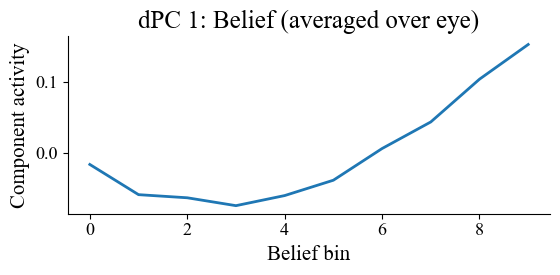

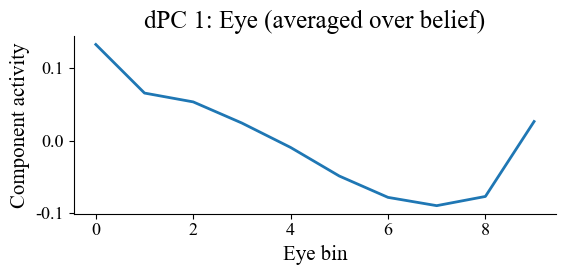

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dPCA.dPCA import dPCA

# === Load data ===
fr = np.vstack(timedf['PPC'].to_numpy())           # [T_total, N_neurons]
belief = np.vstack(timedf['belief'].to_numpy())    # [T_total, 1]
eye = np.vstack(timedf['eye'].to_numpy())          # [T_total, 1]

n_neurons = fr.shape[1]
n_bins_belief = 10
n_bins_eye = 10

# === Bin belief and eye ===
belief_bin = pd.qcut(belief.flatten(), q=n_bins_belief, labels=False)
eye_bin = pd.qcut(eye.flatten(), q=n_bins_eye, labels=False, duplicates='drop')

# === Build tensor: [neurons, belief_bin, eye_bin] ===
X = np.full((n_neurons, n_bins_belief, n_bins_eye), np.nan)

for b in range(n_bins_belief):
    for e in range(n_bins_eye):
        idx = (belief_bin == b) & (eye_bin == e)
        if np.any(idx):
            fr_slice = fr[idx]                     # [samples x neurons]
            X[:, b, e] = np.nanmean(fr_slice, axis=0)

# === Fill missing values with neuron-wise mean ===
X_mean = np.nanmean(X, axis=(1, 2), keepdims=True)
X = np.where(np.isnan(X), X_mean, X)

# === Run dPCA ===
dpca = dPCA(labels='be', regularizer=1e-5)
Z = dpca.fit_transform(X)

# === Plot dPCs ===

# --- Belief component (mean over eye) ---
plt.figure(figsize=(6, 3))
plt.plot(np.mean(Z['b'][0], axis=1))  # shape [belief]
plt.title("dPC 1: Belief (averaged over eye)")
plt.xlabel("Belief bin")
plt.ylabel("Component activity")
plt.tight_layout()
plt.show()

# --- Eye component (mean over belief) ---
plt.figure(figsize=(6, 3))
plt.plot(np.mean(Z['e'][0], axis=0))  # shape [eye]
plt.title("dPC 1: Eye (averaged over belief)")
plt.xlabel("Eye bin")
plt.ylabel("Component activity")
plt.tight_layout()
plt.show()


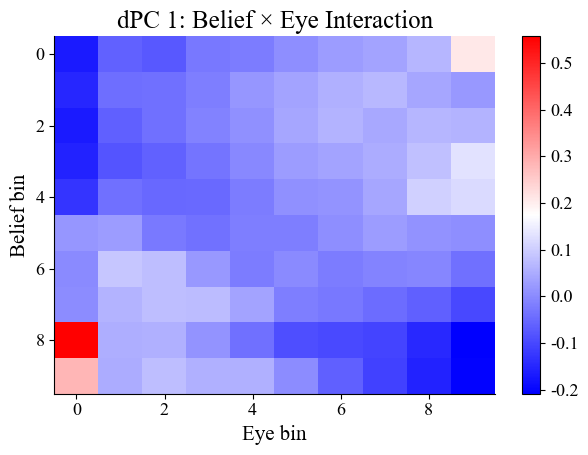

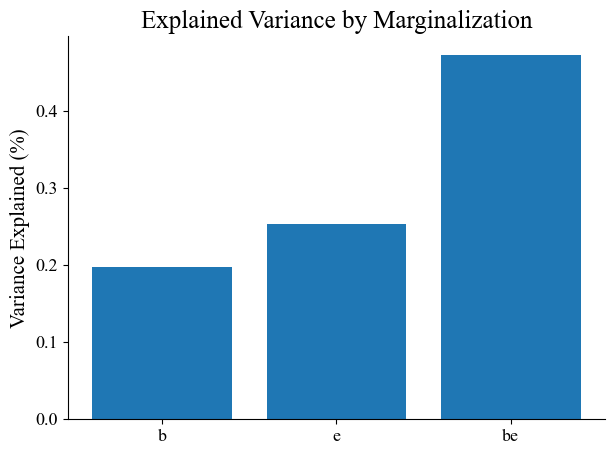

In [24]:
plt.imshow(Z['be'][0], aspect='auto', cmap='bwr')  # shape: [belief_bin, eye_bin]
plt.colorbar()
plt.title("dPC 1: Belief × Eye Interaction")
plt.xlabel("Eye bin")
plt.ylabel("Belief bin")
plt.tight_layout()
plt.show()
expl_var = dpca.explained_variance_ratio_
plt.bar(expl_var.keys(), [np.sum(v) for v in expl_var.values()])
plt.title("Explained Variance by Marginalization")
plt.ylabel("Variance Explained (%)")
plt.tight_layout()
plt.show()


In [ ]:
neural_data = np.vstack(timedf['PPC'].to_numpy())        # [T, N]
eye_data = np.vstack(timedf['eye'].to_numpy())           # [T, 1]
belief_data = np.vstack(timedf['belief'].to_numpy())     # [T, 1]

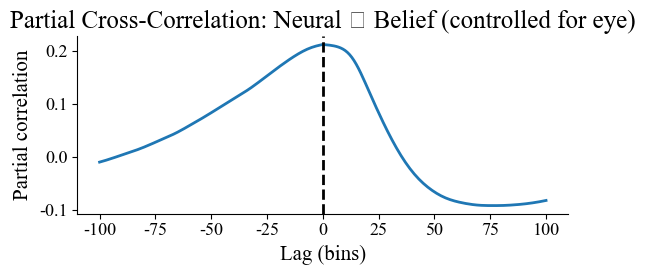

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.signal import correlate

# === Load data ===
neural_data = np.vstack(timedf['PPC'].to_numpy())     # [T, N]
belief_data = np.vstack(timedf['belief'].to_numpy())  # [T, 1]
eye_data = np.vstack(timedf['eye'].to_numpy())        # [T, 1]
trial_id = timedf['trial'].to_numpy()                 # [T]

# === Get population activity ===
pop_activity = neural_data.mean(axis=1, keepdims=True)  # [T, 1]

# === Detrend per trial (demean optional) ===
def zscore_within_trials(x, trial_id):
    return np.concatenate([
        (x[trial_id == tid] - np.mean(x[trial_id == tid])) / (np.std(x[trial_id == tid]) + 1e-6)
        for tid in np.unique(trial_id)
    ])

pop_z = zscore_within_trials(pop_activity, trial_id)
belief_z = zscore_within_trials(belief_data, trial_id)
eye_z = zscore_within_trials(eye_data, trial_id)

# === Partial out eye from both belief and neural ===
reg_eye_on_belief = LinearRegression().fit(eye_z, belief_z)
belief_resid = belief_z - reg_eye_on_belief.predict(eye_z)

reg_eye_on_neural = LinearRegression().fit(eye_z, pop_z)
neural_resid = pop_z - reg_eye_on_neural.predict(eye_z)

# === Compute cross-correlation ===
max_lag = 100  # in time bins (adjust if needed)
corr = correlate(neural_resid[:, 0], belief_resid[:, 0], mode='full', method='auto')
lags = np.arange(-len(neural_resid) + 1, len(neural_resid))

# Restrict to desired lag window
center = len(corr) // 2
lag_idx = np.arange(center - max_lag, center + max_lag + 1)
corr = corr[lag_idx]
lags = lags[lag_idx]

# Normalize correlation
corr /= np.std(neural_resid) * np.std(belief_resid) * len(neural_resid)

# === Plot ===
plt.figure(figsize=(6, 3))
plt.plot(lags, corr)
plt.axvline(0, color='k', linestyle='--')
plt.title("Partial Cross-Correlation: Neural ⟷ Belief (controlled for eye)")
plt.xlabel("Lag (bins)")
plt.ylabel("Partial correlation")
plt.tight_layout()
plt.show()


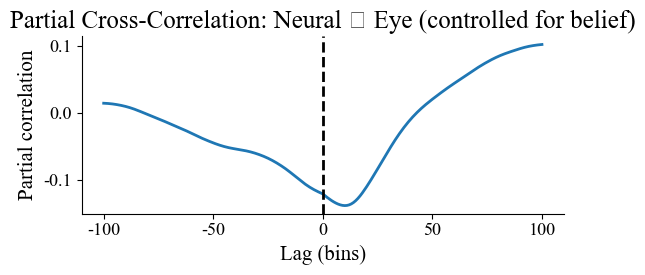

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.signal import correlate

# === Load data ===
neural_data = np.vstack(timedf['PPC'].to_numpy())     # [T, N]
belief_data = np.vstack(timedf['belief'].to_numpy())  # [T, 1]
eye_data = np.vstack(timedf['eye'].to_numpy())        # [T, 1]
trial_id = timedf['trial'].to_numpy()                 # [T]

# === Get population activity ===
pop_activity = neural_data.mean(axis=1, keepdims=True)  # [T, 1]

# === Detrend per trial (demean + z-score) ===
def zscore_within_trials(x, trial_id):
    return np.concatenate([
        (x[trial_id == tid] - np.mean(x[trial_id == tid])) / (np.std(x[trial_id == tid]) + 1e-6)
        for tid in np.unique(trial_id)
    ])

pop_z = zscore_within_trials(pop_activity, trial_id)
belief_z = zscore_within_trials(belief_data, trial_id)
eye_z = zscore_within_trials(eye_data, trial_id)

# === Partial out belief from both neural and eye ===
reg_belief_on_eye = LinearRegression().fit(belief_z, eye_z)
eye_resid = eye_z - reg_belief_on_eye.predict(belief_z)

reg_belief_on_neural = LinearRegression().fit(belief_z, pop_z)
neural_resid = pop_z - reg_belief_on_neural.predict(belief_z)

# === Compute cross-correlation ===
max_lag = 100  # in time bins
corr = correlate(neural_resid[:, 0], eye_resid[:, 0], mode='full', method='auto')
lags = np.arange(-len(neural_resid) + 1, len(neural_resid))

# Restrict to desired lag window
center = len(corr) // 2
lag_idx = np.arange(center - max_lag, center + max_lag + 1)
corr = corr[lag_idx]
lags = lags[lag_idx]

# Normalize correlation
corr /= np.std(neural_resid) * np.std(eye_resid) * len(neural_resid)

# === Plot ===
plt.figure(figsize=(6, 3))
plt.plot(lags, corr)
plt.axvline(0, color='k', linestyle='--')
plt.title("Partial Cross-Correlation: Neural ⟷ Eye (controlled for belief)")
plt.xlabel("Lag (bins)")
plt.ylabel("Partial correlation")
plt.tight_layout()
plt.show()


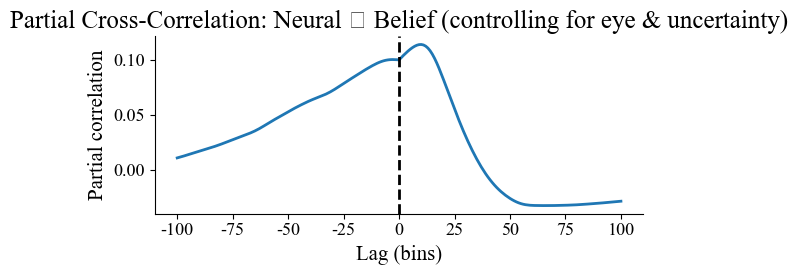

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.signal import correlate

# Load the required data arrays
neural_data = np.vstack(timedf['PPC'].to_numpy())     # [T, N]
belief_data = np.vstack(timedf['belief'].to_numpy())  # [T, 1]
eye_data = np.vstack(timedf['eye'].to_numpy())        # [T, 1]
uncertainty_data = np.array([u[0, 0] for u in timedf['uncertainty'].to_numpy()]).reshape(-1, 1)
trial_id = timedf['trial'].to_numpy()                 # [T]

# Compute population activity
pop_activity = neural_data.mean(axis=1, keepdims=True)  # [T, 1]

# Detrend per trial
def zscore_within_trials(x, trial_id):
    return np.concatenate([
        (x[trial_id == tid] - np.mean(x[trial_id == tid])) / (np.std(x[trial_id == tid]) + 1e-6)
        for tid in np.unique(trial_id)
    ])

pop_z = zscore_within_trials(pop_activity, trial_id)
belief_z = zscore_within_trials(belief_data, trial_id)
eye_z = zscore_within_trials(eye_data, trial_id)
uncert_z = zscore_within_trials(uncertainty_data, trial_id)

# Regress out uncertainty and eye from belief
X_confounds = np.hstack([eye_z, uncert_z])
reg = LinearRegression().fit(X_confounds, belief_z)
belief_resid = belief_z - reg.predict(X_confounds)

# Regress out uncertainty and eye from neural
reg = LinearRegression().fit(X_confounds, pop_z)
neural_resid = pop_z - reg.predict(X_confounds)

# Compute cross-correlation
max_lag = 100
corr = correlate(neural_resid[:, 0], belief_resid[:, 0], mode='full')
lags = np.arange(-len(neural_resid) + 1, len(neural_resid))

# Trim to lag window
center = len(corr) // 2
lag_idx = np.arange(center - max_lag, center + max_lag + 1)
corr = corr[lag_idx]
lags = lags[lag_idx]

# Normalize
corr /= np.std(neural_resid) * np.std(belief_resid) * len(neural_resid)

# Plot
plt.figure(figsize=(6, 3))
plt.plot(lags, corr)
plt.axvline(0, color='k', linestyle='--')
plt.title("Partial Cross-Correlation: Neural ⟷ Belief (controlling for eye & uncertainty)")
plt.xlabel("Lag (bins)")
plt.ylabel("Partial correlation")
plt.tight_layout()
plt.show()


Fitting Graphical Lasso on neural + belief + eye...


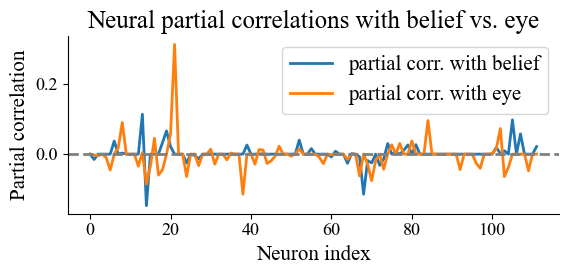

In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV
import matplotlib.pyplot as plt

# ==== Step 1: Bin time ====

bin_size = 20  # adjust based on 0.006s per sample ≈ 120 ms
n_total = len(timedf)
n_bins = n_total // bin_size

def bin_and_average(data):
    data = np.vstack(data)[:n_bins * bin_size]
    return data.reshape(n_bins, bin_size, -1).mean(axis=1)

# Extract and bin
neural = bin_and_average(timedf['PPC'])           # [T_bins, N]
belief = bin_and_average(timedf['belief'])        # [T_bins, 1]
eye = bin_and_average(timedf['eye'])              # [T_bins, 1]

# ==== Step 2: Stack features ====

X = np.hstack([neural, belief, eye])  # [T_bins, N + 2]

# Standardize
X = StandardScaler().fit_transform(X)

# ==== Step 3: Fit Graphical Lasso ====

print("Fitting Graphical Lasso on neural + belief + eye...")
model = GraphicalLassoCV()
model.fit(X)

precision = model.precision_
n_neurons = neural.shape[1]
labels = [f'N{i}' for i in range(n_neurons)] + ['belief', 'eye']

# ==== Step 4: Extract partial correlation ====

# Helper to get partial corr. from precision
def partial_corr(precision_matrix, i, j):
    return -precision_matrix[i, j] / (
        np.sqrt(precision_matrix[i, i] * precision_matrix[j, j]) + 1e-8
    )

# Partial corr. between each neuron and belief
idx_belief = labels.index('belief')
belief_pc = [
    partial_corr(precision, i, idx_belief) for i in range(n_neurons)
]

# Partial corr. between each neuron and eye
idx_eye = labels.index('eye')
eye_pc = [
    partial_corr(precision, i, idx_eye) for i in range(n_neurons)
]

# ==== Step 5: Plot ====

plt.figure(figsize=(6, 3))
plt.plot(belief_pc, label='partial corr. with belief')
plt.plot(eye_pc, label='partial corr. with eye')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Neuron index")
plt.ylabel("Partial correlation")
plt.title("Neural partial correlations with belief vs. eye")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Simulated data loading (will be replaced with user's `timedf`)
# timedf = pd.read_pickle("timedf.pkl")

# === Extract variables ===
fr = np.vstack(timedf['PPC'].to_numpy())[:,:10]           # [T, N]
belief = np.vstack(timedf['belief'].to_numpy())     # [T, 1]
eye = np.vstack(timedf['eye'].to_numpy())           # [T, 1]
timer = timedf['timer'].to_numpy().reshape(-1, 1)   # [T, 1]
uncert = np.array([x[0, 0] for x in timedf['uncertainty'].to_numpy()]).reshape(-1, 1)  # [T, 1]
fullon = timedf['fullon'].to_numpy().astype(bool)   # [T]



# === Standardize predictors ===
scaler = StandardScaler()
X = scaler.fit_transform(np.hstack([belief, eye, timer, uncert]))  # [T, 4]
y = fr  # [T, N]

# === Split data ===
X_fullon = X[fullon]
y_fullon = y[fullon]
X_partial = X[~fullon]
y_partial = y[~fullon]

# === Function: Train Ridge and get CV R² ===
def ridge_cv_r2(X, y):
    r2s = []
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    for i in range(y.shape[1]):
        model = Ridge(alpha=1.0)
        scores = cross_val_score(model, X, y[:, i], cv=kf, scoring='r2')
        r2s.append(np.mean(scores))
    return np.array(r2s)

# === Function: Train Random Forest decoding model ===
def decode_uncertainty(X, y):
    rf = RandomForestRegressor(n_estimators=100, random_state=0)
    scores = cross_val_score(rf, X, y.ravel(), cv=5, scoring='r2')
    return np.mean(scores)

# === Run Ridge GLM Encoding ===
glm_r2_fullon = ridge_cv_r2(X_fullon, y_fullon)
glm_r2_partial = ridge_cv_r2(X_partial, y_partial)

# === Run decoding (population to uncertainty) ===
decoding_r2_fullon = decode_uncertainty(y_fullon, uncert[fullon])
decoding_r2_partial = decode_uncertainty(y_partial, uncert[~fullon])

# === Plot Encoding Performance Comparison ===
plt.figure(figsize=(6, 3))
plt.bar(['Full-on', 'Partial'], [np.mean(glm_r2_fullon), np.mean(glm_r2_partial)], color=['steelblue', 'tomato'])
plt.ylabel('Mean pseudo-R² (GLM)')
plt.title('Uncertainty Encoding (GLM)')
plt.tight_layout()
plt.show()

# === Plot Decoding Performance ===
plt.figure(figsize=(6, 3))
plt.bar(['Full-on', 'Partial'], [decoding_r2_fullon, decoding_r2_partial], color=['steelblue', 'tomato'])
plt.ylabel('R² (Decoding from Neural → Uncertainty)')
plt.title('Uncertainty Decoding')
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

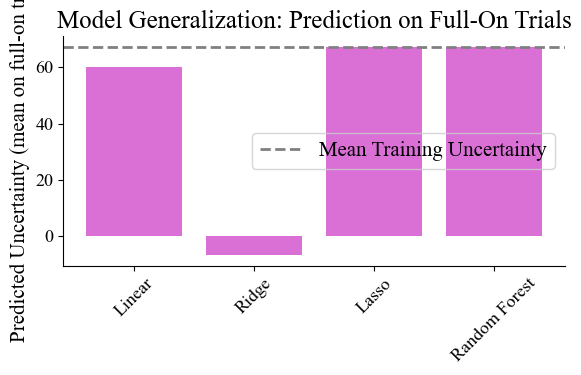

Mean predicted uncertainty on full-on trials:
Linear         : 60.0978 (train mean: 67.3477)
Ridge          : -6.7597 (train mean: 67.3480)
Lasso          : 67.3477 (train mean: 67.3477)
Random Forest  : 67.2944 (train mean: 67.3477)


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# === Extract data ===
fr = np.vstack(timedf['PPC'].to_numpy())            # [T, N]
uncertainty = np.array([u[0, 0] for u in timedf['uncertainty'].to_numpy()]).reshape(-1, 1)  # [T, 1]
fullon = timedf['fullon'].to_numpy()                # [T]

# === Standardize firing rates ===
scaler = StandardScaler()
fr_std = scaler.fit_transform(fr)

# === Split ===
X_train = fr_std[~fullon]
y_train = uncertainty[~fullon]
X_test = fr_std[fullon]
y_test = uncertainty[fullon]

# === Define models ===
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=0),
}

# === Fit and predict ===
preds_test = {}
preds_train = {}
for name, model in models.items():
    model.fit(X_train, y_train.ravel())
    preds_test[name] = model.predict(X_test)
    preds_train[name] = model.predict(X_train)

# === Compare predicted uncertainty ===
mean_preds_test = {k: np.mean(v) for k, v in preds_test.items()}
mean_preds_train = {k: np.mean(v) for k, v in preds_train.items()}

# === Plot predicted uncertainty ===
plt.figure(figsize=(6, 4))
plt.bar(mean_preds_test.keys(), mean_preds_test.values(), color='orchid')
plt.ylabel("Predicted Uncertainty (mean on full-on trials)")
plt.title("Model Generalization: Prediction on Full-On Trials")
plt.axhline(np.mean(y_train), color='gray', linestyle='--', label='Mean Training Uncertainty')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Print comparison table ===
print("Mean predicted uncertainty on full-on trials:")
for name in models:
    print(f"{name:15s}: {mean_preds_test[name]:.4f} (train mean: {mean_preds_train[name]:.4f})")


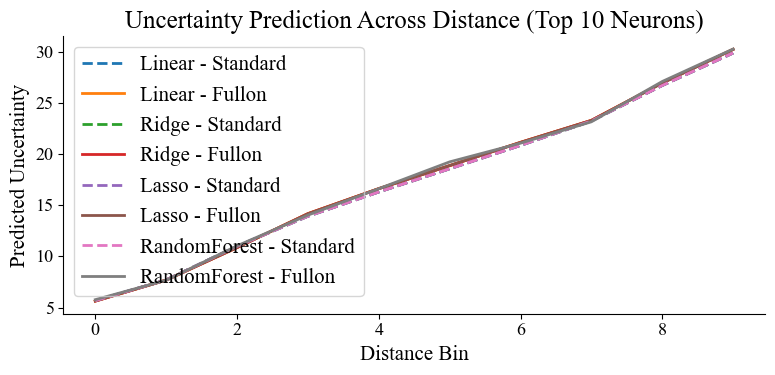

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

DT = 0.006
timedf['distance_traveled'] = timedf.groupby('trial')['mv'].transform(lambda v: np.cumsum(v) * DT)
timedf['dist_bin'] = pd.qcut(timedf['distance_traveled'], q=10, labels=False, duplicates='drop')

# Extract neural data and target
neural_data = np.vstack(timedf['PPC'].to_numpy())          # [T, N]
uncertainty = np.array([u[0] for u in timedf['uncertainty'].to_numpy()])
is_standard = ~timedf['fullon'].to_numpy()

# === Select top 10 neurons based on linear regression R² (standard trials only) ===
r2_scores = []
for i in range(neural_data.shape[1]):
    X_i = neural_data[is_standard, i].reshape(-1, 1)
    y = uncertainty[is_standard]
    model = LinearRegression().fit(X_i, y)
    r2 = model.score(X_i, y)
    r2_scores.append(r2)

top_neuron_idx = np.argsort(r2_scores)[-10:]
neural_data = neural_data[:, top_neuron_idx]

# Standardize neural data
scaler = StandardScaler()
neural_data_scaled = scaler.fit_transform(neural_data)

# Initialize model families
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=0)
}

results = {name: {'standard': [], 'fullon': []} for name in models}

# Iterate over distance bins
for b in sorted(timedf['dist_bin'].dropna().unique()):
    idx_bin = timedf['dist_bin'] == b
    idx_train = idx_bin & (~timedf['fullon'])
    idx_test = idx_bin & timedf['fullon']

    if idx_train.sum() < 10 or idx_test.sum() < 10:
        continue

    X_train = neural_data_scaled[idx_train]
    y_train = uncertainty[idx_train]
    X_test = neural_data_scaled[idx_test]

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results[name]['standard'].append(np.mean(y_train))
        results[name]['fullon'].append(np.mean(y_pred))

# Plot
plt.figure(figsize=(8, 4))
bins = sorted(timedf['dist_bin'].dropna().unique())
for name in models:
    plt.plot(bins, results[name]['standard'], label=f"{name} - Standard", linestyle='--')
    plt.plot(bins, results[name]['fullon'], label=f"{name} - Fullon")

plt.xlabel("Distance Bin")
plt.ylabel("Predicted Uncertainty")
plt.title("Uncertainty Prediction Across Distance (Top 10 Neurons)")
plt.legend()
plt.tight_layout()
plt.show()


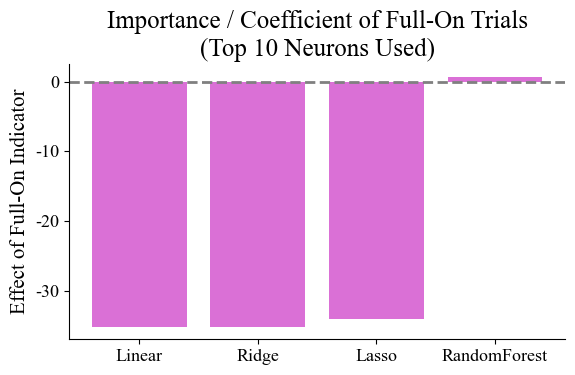

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# --- Setup ---
DT = 0.006

# Compute distance traveled and bin
timedf['distance_traveled'] = timedf.groupby('trial')['mv'].transform(lambda v: np.cumsum(v) * DT)
timedf['dist_bin'] = pd.qcut(timedf['distance_traveled'], q=10, labels=False, duplicates='drop')

# Extract relevant data
neural_data = np.vstack(timedf['PPC'].to_numpy())                      # [T, N]
uncertainty = np.array([u[0] for u in timedf['uncertainty'].to_numpy()])  # [T,]
fullon_flag = timedf['fullon'].astype(int).to_numpy()                 # [T,]
is_standard = ~timedf['fullon'].to_numpy()

# --- Select Top 10 Neurons ---
r2_scores = []
for i in range(neural_data.shape[1]):
    X_i = neural_data[is_standard, i].reshape(-1, 1)
    y = uncertainty[is_standard]
    model = LinearRegression().fit(X_i, y)
    r2_scores.append(model.score(X_i, y))

top_idx = np.argsort(r2_scores)[-10:]
neural_data = neural_data[:, top_idx]

# --- Standardize neural data ---
scaler = StandardScaler()
neural_data_scaled = scaler.fit_transform(neural_data)

# --- Add fullon flag to inputs ---
X_all = np.hstack([neural_data_scaled, fullon_flag.reshape(-1, 1)])  # [T, 11]

# --- Define models ---
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=0)
}

# --- Fit models and extract fullon effect ---
fullon_effect = {}
for name, model in models.items():
    model.fit(X_all, uncertainty)
    if hasattr(model, 'coef_'):
        coef = model.coef_
        # If it's 1D (e.g., [10 + 1]), just get the last element
        if coef.ndim == 1:
            fullon_effect[name] = float(coef[-1])
        # If it's 2D (e.g., [1, 11]), also get last element from first row
        elif coef.ndim == 2:
            fullon_effect[name] = float(coef[0, -1])
    elif hasattr(model, 'feature_importances_'):
        fullon_effect[name] = float(model.feature_importances_[-1])

# --- Plot ---
plt.figure(figsize=(6, 4))
plt.bar(list(fullon_effect.keys()), list(fullon_effect.values()), color='orchid')
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel("Effect of Full-On Indicator")
plt.title("Importance / Coefficient of Full-On Trials\n(Top 10 Neurons Used)")
plt.tight_layout()
plt.show()


In [50]:
np.cumsum(timedf[timedf['trial']==10].mv)*DT

2071      1.092510
2072      2.184932
2073      3.277227
2074      4.369726
2075      5.462167
           ...    
2286    231.097366
2287    231.233749
2288    231.368179
2289    231.430267
2290    231.502411
Name: mv, Length: 220, dtype: float32

In [ ]:
1/0

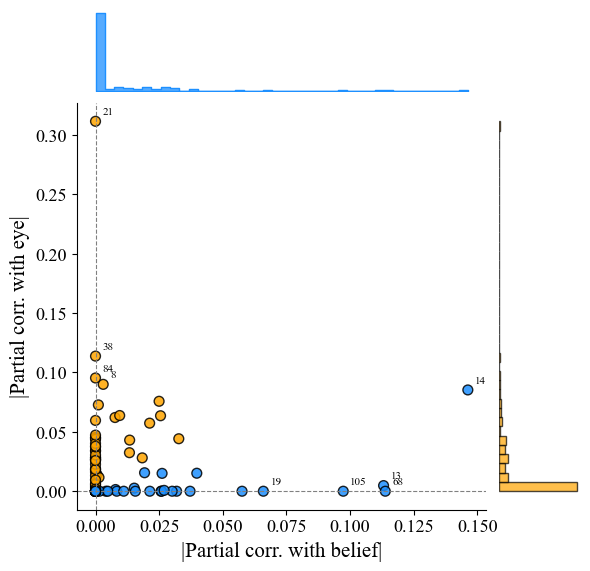

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Input data ===
belief_pc = np.abs(np.array(belief_pc))
eye_pc = np.abs(np.array(eye_pc))
dominance = np.where(belief_pc >= eye_pc, 'belief', 'eye')
colors = np.where(dominance == 'belief', 'dodgerblue', 'orange')

# Annotate top N
N = 5
top_belief = np.argsort(-belief_pc)[:N]
top_eye = np.argsort(-eye_pc)[:N]
annotate_idx = np.unique(np.concatenate([top_belief, top_eye]))

# === Set up plot ===
fig = plt.figure(figsize=(6.5, 6.5))
gs = fig.add_gridspec(2, 2, width_ratios=(5, 1), height_ratios=(1, 5), hspace=0.05, wspace=0.05)
ax_scatter = fig.add_subplot(gs[1, 0])
ax_xhist = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_yhist = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# === Scatter ===
ax_scatter.scatter(belief_pc, eye_pc, c=colors, edgecolor='k', alpha=0.85, s=50)
ax_scatter.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_scatter.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax_scatter.set_xlabel("|Partial corr. with belief|")
ax_scatter.set_ylabel("|Partial corr. with eye|")
# ax_scatter.set_title("Belief vs. Eye Encoding (abs partial corr)")

# === Annotate top neurons ===
for i in annotate_idx:
    ax_scatter.annotate(str(i), (belief_pc[i], eye_pc[i]),
                        textcoords="offset points", xytext=(5, 5),
                        ha='left', fontsize=8, color='black')

# === X histogram using seaborn ===
sns.histplot(belief_pc, bins=40, ax=ax_xhist, color='dodgerblue',
             element="step", stat="density")
ax_xhist.axis('off')

# === Y histogram using matplotlib ===
ax_yhist.hist(eye_pc, bins=40, orientation='horizontal',
              color='orange', edgecolor='k', alpha=0.7, density=True)
ax_yhist.axis('off')

# === Final layout ===
plt.subplots_adjust(hspace=0.05, wspace=0.05)
plt.show()


# plots

In [20]:
notify('done')